## LIBRERÍA

In [1]:
!pip install ipfn

In [2]:
#!conda install -y pyarrow
#! pip install pyreadr
from sqlalchemy import create_engine
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import mapclassify 
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import numpy as np
import pyreadr
from sklearn.linear_model import LinearRegression
from ipfn import ipfn
import contextlib
import io
import warnings

In [3]:
RUTA_CENSO_ZONAL = '../Parquet/Cartografía_censo2024_R13_Zonal.parquet'
RUTA_CASEN = '../Parquet/casen_rm.rds'

## ENTRADAS

In [4]:
censo_zonal = gpd.read_parquet(RUTA_CENSO_ZONAL)
casen_raw = pyreadr.read_r(RUTA_CASEN)
##se transforma la CASEN a DF
casen_raw = casen_raw[list(casen_raw.keys())[0]]

In [5]:
## SEMILLA
SEED = 123

## PRE-PROCESAMIENTO

Se acota el área del censo únicamente utilizando zonas censales del Gran Santiago

In [6]:
## CONDICIÓN
es_gs = (censo_zonal["PROVINCIA"] == 'SANTIAGO') | (
    censo_zonal["COMUNA"].isin(['SAN BERNARDO', 'PUENTE ALTO'])
)

## SE FILTRA EL DF EN BASE A LA CONDICIÓN
censo_zonal = censo_zonal[es_gs].reset_index(drop=True)

In [7]:
## VARIABLE QUE NO SE TOCAN PARA MICROSIMULAR.
## EN CASO DE AÑADIR UNA NUEVA EL PROCESAMIENTO POSTERIOR CAMBIA
VARS_FIJAS = ["estrato","esc","e6a","edad","sexo",
              "v13","v13_propia","v13_arrendada","v13_cedida"]

## ESTA ES LA QUE SE MODIFICA
VARIABLE_A_MICROSIMULAR = "ypchtrabcor" #Este es el nombre de la variable que se microsimula
FUNCION_AGREGACION = np.median 

vars_a_cargar = VARS_FIJAS + [VARIABLE_A_MICROSIMULAR]

## SE ACOTA LA CASEN ÚNICAMENTE A LAS VARIABLES A UTILIZAR
casen = casen_raw[vars_a_cargar].copy()

del casen_raw ##PARA LIBERAR MEMORIA

## SE OBTIENE LA COMUNA DE CADA PERSONA
casen["comuna"] = (casen["estrato"]//100).astype("int64")
casen = casen.drop(columns="estrato")

comunas_gs = censo_zonal["CUT"].unique()
casen = casen[casen["comuna"].isin(comunas_gs)].reset_index(drop=True)

casen

,esc,e6a,edad,sexo,v13,v13_propia,v13_arrendada,v13_cedida,ypchtrabcor,comuna
0,12.0,11.0,54.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
1,12.0,11.0,28.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
2,17.0,13.0,27.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
3,10.0,11.0,19.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
4,12.0,11.0,56.0,1.0,1.0,2.0,NaN,NaN,520000.0,13111
...,...,...,...,...,...,...,...,...,...,...
32202,8.0,7.0,56.0,2.0,1.0,2.0,NaN,NaN,540787.0,13115
32203,12.0,11.0,33.0,1.0,3.0,NaN,NaN,8.0,209696.0,13115
32204,14.0,12.0,31.0,2.0,3.0,NaN,NaN,8.0,209696.0,13115
32205,NaN,7.0,10.0,1.0,3.0,NaN,NaN,8.0,209696.0,13115


In [8]:
ZONA_ID = "OBJECTID"

COLS_SEXO = {"hombre": "n_hombres", "mujer": "n_mujeres"}
COLS_EDAD = {
    "edad_0_5": "n_edad_0_5",
    "edad_6_13": "n_edad_6_13",
    "edad_14_17": "n_edad_14_17",
    "edad_18_24": "n_edad_18_24",
    "edad_25_44": "n_edad_25_44",
    "edad_45_59": "n_edad_45_59",
    "edad_60_mas": "n_edad_60_mas",
}

COLS_EDUC = ["educ_nunca", "educ_primaria", "educ_secundaria", "educ_terciaria"]

COLS_TENENCIA = {
    "ten_propia_pagada": "n_tenencia_propia_pagada",
    "ten_propia_pagandose": "n_tenencia_propia_pagandose",
    "ten_arrendada_contrato": "n_tenencia_arrendada_contrato",
    "ten_arrendada_sin_contrato": "n_tenencia_arrendada_sin_contrato",
    "ten_cedida_trabajo": "n_tenencia_cedida_trabajo",
    "ten_cedida_familiar": "n_tenencia_cedida_familiar",
    "ten_otro": "n_tenencia_otro",
}

constraints = censo_zonal[[ZONA_ID, "CUT", "COMUNA", "n_per", "n_hog"]].copy()

for nombre,col in {**COLS_SEXO, **COLS_EDAD}.items():
    constraints[nombre] = censo_zonal[col]

# Para educación tendremos 4 niveles
constraints["educ_nunca"] = censo_zonal["n_cine_nunca_curso_primera_infancia"]
constraints["educ_primaria"] = (censo_zonal["n_cine_primaria"] + 
                               censo_zonal["n_cine_especial_diferencial"])
constraints["educ_secundaria"] = censo_zonal["n_cine_secundaria"]
constraints["educ_terciaria"] = censo_zonal["n_cine_terciaria_maestria_doctorado"]

# Se calculan personas por hogar
personas_por_hogar = np.where(
    censo_zonal["n_hog"] > 0, censo_zonal["n_per"] / censo_zonal["n_hog"], 0
)
for nombre, col in COLS_TENENCIA.items():
    constraints[nombre] = censo_zonal[col] * personas_por_hogar

# Se ordenan las categorías
CATEGORIAS = {
    "sexo_cat": list(COLS_SEXO.keys()),
    "edad_cat": list(COLS_EDAD.keys()),
    "educ_cat": COLS_EDUC,
    "tenencia_cat": list(COLS_TENENCIA.keys()),
}

constraints = constraints.set_index(ZONA_ID)

In [9]:
constraints

,CUT,COMUNA,n_per,n_hog,hombre,mujer,edad_0_5,edad_6_13,edad_14_17,edad_18_24,...,educ_primaria,educ_secundaria,educ_terciaria,ten_propia_pagada,ten_propia_pagandose,ten_arrendada_contrato,ten_arrendada_sin_contrato,ten_cedida_trabajo,ten_cedida_familiar,ten_otro
OBJECTID,,,,,,,,,,,,,,,,,,,,,
2702,13107,HUECHURABA,4776.0,1408.0,2294.0,2482.0,209.0,658.0,403.0,541.0,...,1192.0,955.0,2369.0,803.914773,2954.471591,844.619318,64.448864,6.784091,78.017045,23.744318
2703,13107,HUECHURABA,7091.0,1898.0,3386.0,3705.0,314.0,862.0,633.0,1024.0,...,1672.0,1605.0,3418.0,1584.080084,4584.118546,735.999473,52.304531,14.944152,70.984721,44.832455
2704,13107,HUECHURABA,4991.0,1604.0,2364.0,2627.0,322.0,598.0,241.0,446.0,...,1443.0,1556.0,1593.0,1954.082294,1689.596633,849.465711,239.592893,15.557980,174.249377,65.343516
2705,13107,HUECHURABA,6898.0,2178.0,3321.0,3577.0,411.0,892.0,435.0,714.0,...,1451.0,1303.0,3648.0,1079.989899,4278.786961,1361.864096,53.841139,19.002755,88.679522,15.835629
2706,13107,HUECHURABA,5768.0,1912.0,2748.0,3020.0,348.0,670.0,329.0,604.0,...,1484.0,1389.0,2459.0,1357.531381,2371.154812,1478.200837,229.271967,27.150628,238.322176,60.334728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4487,13123,PROVIDENCIA,3491.0,1466.0,1539.0,1952.0,150.0,250.0,131.0,357.0,...,500.0,872.0,1937.0,1176.366985,473.880628,1393.066166,109.540246,88.108458,209.555252,40.482265
4488,13123,PROVIDENCIA,1553.0,854.0,745.0,808.0,51.0,72.0,33.0,123.0,...,155.0,326.0,1010.0,334.604215,214.583138,829.236534,76.377049,21.822014,63.647541,12.729508
4526,13118,MACUL,3120.0,1088.0,1483.0,1637.0,127.0,293.0,154.0,300.0,...,1066.0,1029.0,857.0,1502.647059,324.044118,688.235294,255.220588,17.205882,281.029412,51.617647


## PRE-PROCESAMIENTO Y RECODIFICACIÓN DE LA CASEN
Se recategorizan las distintas variables de aacuerdo a como se dejaron en el CENSO

In [10]:
## IMPUTACIÓN DE ESC EN BASE A E6A

falta_esc = casen["esc"].isna()
print(f"faltan {falta_esc.sum()} de {len(casen)} registros.")

# Regresión Lineal para imputar esc
modelo_esc = LinearRegression().fit(
     casen.loc[~falta_esc, ["e6a"]], casen.loc[~falta_esc, "esc"]
)

# Se predice la escolaridad únicamente para los registros sin esc
pred = modelo_esc.predict(casen.loc[falta_esc, ["e6a"]])
casen.loc[falta_esc, "esc"] = np.clip(np.round(pred), 0, 20)


faltan 5802 de 32207 registros.


In [11]:
# Recodificación de categorías del censo

## Sexo
casen["sexo_cat"] = casen["sexo"].map({1: "hombre", 2: "mujer"})

## Edad
casen["edad_cat"] = pd.cut(
    casen["edad"],
    bins=[0, 6, 14, 18, 25, 45, 60, np.inf],
    labels=list(COLS_EDAD.keys()),
    right=False,
    include_lowest=True,
).astype(str)

## Educación
casen["educ_cat"] = pd.cut(
    casen["esc"],
    bins=[-1, 0, 8, 12, np.inf],
    labels=COLS_EDUC,
).astype(str)

## Tenencia de vivienda
condiciones = [
    (casen["v13"] == 1) & (casen["v13_propia"] == 1),
    (casen["v13"] == 1) & (casen["v13_propia"] == 2),
    (casen["v13"] == 2) & (casen["v13_arrendada"] == 5),
    (casen["v13"] == 2) & (casen["v13_arrendada"] == 6),
    (casen["v13"] == 3) & (casen["v13_cedida"] == 7),
    (casen["v13"] == 3) & (casen["v13_cedida"] == 8),
]
categorias_tenencia = [
    "ten_propia_pagada",
    "ten_propia_pagandose",
    "ten_arrendada_contrato",
    "ten_arrendada_sin_contrato",
    "ten_cedida_trabajo",
    "ten_cedida_familiar",
]
casen["tenencia_cat"] = np.select(condiciones, categorias_tenencia, default="ten_otro")

casen["ID"] = np.arange(len(casen))

# sin la variable a microsimular, la persona no puede ser "donante"
sin_valor = casen[VARIABLE_A_MICROSIMULAR].isna()
print(f"Personas excluidas del pool de donantes por {VARIABLE_A_MICROSIMULAR} faltante: {sin_valor.sum()}")
casen = casen[~sin_valor].reset_index(drop=True)

casen[["comuna", "sexo_cat", "edad_cat", "educ_cat", "tenencia_cat", VARIABLE_A_MICROSIMULAR, "ID"]]

Personas excluidas del pool de donantes por ypchtrabcor faltante: 0


,comuna,sexo_cat,edad_cat,educ_cat,tenencia_cat,ypchtrabcor,ID
0,13111,mujer,edad_45_59,educ_secundaria,ten_propia_pagandose,520000.0,0
1,13111,mujer,edad_25_44,educ_secundaria,ten_propia_pagandose,520000.0,1
2,13111,mujer,edad_25_44,educ_terciaria,ten_propia_pagandose,520000.0,2
3,13111,mujer,edad_18_24,educ_secundaria,ten_propia_pagandose,520000.0,3
4,13111,hombre,edad_45_59,educ_secundaria,ten_propia_pagandose,520000.0,4
...,...,...,...,...,...,...,...
32202,13115,mujer,edad_45_59,educ_primaria,ten_propia_pagandose,540787.0,32202
32203,13115,hombre,edad_25_44,educ_secundaria,ten_cedida_familiar,209696.0,32203
32204,13115,mujer,edad_25_44,educ_terciaria,ten_cedida_familiar,209696.0,32204
32205,13115,hombre,edad_6_13,educ_primaria,ten_cedida_familiar,209696.0,32205


## ALGORITMO DE MICROSIMULACIÓN

In [12]:
def pesos_por_persona(seed, codigos, celda_a_personas):
    """Ejecuta ipfn sobre la tabla seed (conteo de la muestra CASEN de la
    comuna, en forma de arreglo N-dimensional) contra los objetivos codigos
    (uno por variable-constraint), y devuelve el peso fraccionario que le
    corresponde a CADA PERSONA de la muestra (no a cada celda).
    """
    # ipfn necesita saber qué eje del arreglo seed corresponde a cada variable.
    # Como seed tiene un eje por variable (sexo, edad, educación, tenencia) en
    # ese mismo orden, dims = [[0], [1], [2], [3]]: "el objetivo 0 (sexo) se
    # aplica sobre el eje 0, el objetivo 1 (edad) sobre el eje 1", etc.
    dims = [[i] for i in range(len(codigos["objetivos"]))]

    # Acá es donde ipfn hace TODO el trabajo de reponderar (raking/IPF):
    # ajusta iterativamente la tabla seed hasta que sus marginales calcen
    # con codigos["objetivos"]. .copy() porque ipfn modifica la tabla que
    # recibe, y queremos poder reusar seed para la próxima zona.
    IPF = ipfn.ipfn(
        seed.copy(),
        codigos["objetivos"],
        dims,
        convergence_rate=1e-6,   # qué tan exacto debe quedar el ajuste
        max_iteration=50,        # tope de vueltas si no converge antes
    )
    tabla_reponderada = IPF.iteration()  # arreglo del mismo tamaño que seed,
                                          # pero con los valores ya ajustados

    # codigos["indices"] es una tupla con la "coordenada" de cada persona en
    # la tabla (su combinación exacta de sexo/edad/educación/tenencia). Al usarla
    # para indexar tabla_reponderada, cada persona recibe el peso ajustado de
    # SU celda (varias personas comparten la misma celda si tienen las mismas
    # 4 categorías, y por ahora reciben el mismo número: el peso de la celda).
    peso_celda = tabla_reponderada[codigos["indices"]]

    # Si 3 personas comparten una celda que quedó con peso ajustado 9, cada una
    # debería valer 9/3 = 3 personas, no 9 cada una. Por eso dividimos por
    # cuántas personas hay en esa celda originalmente (celda_a_personas).
    return peso_celda / celda_a_personas


def integerise_trs(pesos, rng):
    """Truncate-Replicate-Sample: pasa de pesos fraccionarios a una población
    entera reproducible. Devuelve un array de índices (posiciones en pesos),
    uno por cada persona sintética generada.
    """
    # Paso 1 (Truncate): separamos cada peso en su parte entera y su resto.
    # Ej. un peso de 2.37 -> parte_entera=2 (esas 2 copias van seguro),
    # parte_fraccionaria=0.37 (0.37 de probabilidad de una 3ª copia).
    parte_entera = np.floor(pesos).astype(int)
    parte_fraccionaria = pesos - parte_entera

    # Paso 2 (Replicate): armamos la lista de copias "seguras". np.repeat(idx, n)
    # repite el índice 0 tantas veces como diga parte_entera[0], el índice 1
    # tantas veces como diga parte_entera[1], etc. Si nadie tiene parte entera
    # (todos los pesos son < 1), esto queda vacío.
    idx = np.arange(len(pesos))
    replicados = np.repeat(idx, parte_entera)

    # ¿Cuántas personas le faltan a esta zona para llegar a su población total?
    # (el total objetivo es la suma de todos los pesos, redondeada)
    n_total = int(round(pesos.sum()))
    n_faltante = n_total - parte_entera.sum()

    # Paso 3 (Sample): completamos lo que falta sorteando personas, dándole más
    # chance de ser sorteada a quien tenga una parte fraccionaria más alta (una
    # persona con 0.9 tiene mucha más chance de la copia extra que una con 0.1).
    if n_faltante > 0 and parte_fraccionaria.sum() > 0:
        probs = parte_fraccionaria / parte_fraccionaria.sum()
        extra = rng.choice(idx, size=n_faltante, replace=True, p=probs)
        replicados = np.concatenate([replicados, extra])

    return replicados

## EJECUCIÓN DEL ALGORITMO

In [13]:
rng = np.random.default_rng(SEED)

VARS_CONSTRAINT = list(CATEGORIAS.keys())  # ["sexo_cat", "edad_cat", "educ_cat", "tenencia_cat"]

resultados_zona = []
zonas_sin_donantes = []

buffer_salida = io.StringIO()
with contextlib.redirect_stdout(buffer_salida), warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    for comuna_cut, cons_comuna in constraints.groupby("CUT"):
        muestra_comuna = casen[casen["comuna"] == comuna_cut]

        if len(muestra_comuna) == 0:
            zonas_sin_donantes.extend(cons_comuna.index.tolist())
            continue

        # tabla de conteo de la muestra (una vez por comuna): igual que en la sección 6
        indices = {
            var: pd.Categorical(muestra_comuna[var], categories=CATEGORIAS[var]).codes
            for var in VARS_CONSTRAINT
        }
        forma = tuple(len(CATEGORIAS[var]) for var in VARS_CONSTRAINT)
        seed_tabla = np.zeros(forma)
        indices_tupla = tuple(indices[var] for var in VARS_CONSTRAINT)
        np.add.at(seed_tabla, indices_tupla, 1)
        celda_a_personas = seed_tabla[indices_tupla]  # cuántas personas comparten la celda de cada persona

        valores_objetivo = muestra_comuna[VARIABLE_A_MICROSIMULAR].to_numpy()

        for zona_id, fila in cons_comuna.iterrows():
            if fila["n_per"] == 0:
                continue

            objetivos = [
                np.array([fila[cat] for cat in CATEGORIAS[var]], dtype=float)
                for var in VARS_CONSTRAINT
            ]

            pesos = pesos_por_persona(
                seed_tabla, {"objetivos": objetivos, "indices": indices_tupla}, celda_a_personas
            )
            sinteticos_idx = integerise_trs(pesos, rng)

            valores_sinteticos = valores_objetivo[sinteticos_idx]

            resultados_zona.append({
                "zona_id": zona_id,
                "CUT": comuna_cut,
                "n_sintetico": len(sinteticos_idx),
                "n_censo": fila["n_per"],
                "valor_zona": FUNCION_AGREGACION(valores_sinteticos) if len(valores_sinteticos) else np.nan,
            })

resultados_zona = pd.DataFrame(resultados_zona).set_index("zona_id")
print(f"Zonas simuladas: {len(resultados_zona)}")
print(f"Zonas sin comuna con donantes CASEN: {len(zonas_sin_donantes)}")
resultados_zona.head()

Zonas simuladas: 1640
Zonas sin comuna con donantes CASEN: 0


,CUT,n_sintetico,n_censo,valor_zona
zona_id,,,,
4309,13101,3918,3923.0,294583.0
4310,13101,6245,6250.0,324583.0
4311,13101,4038,4038.0,347500.0
4312,13101,3050,3050.0,317778.0
4313,13101,5597,5599.0,421667.0


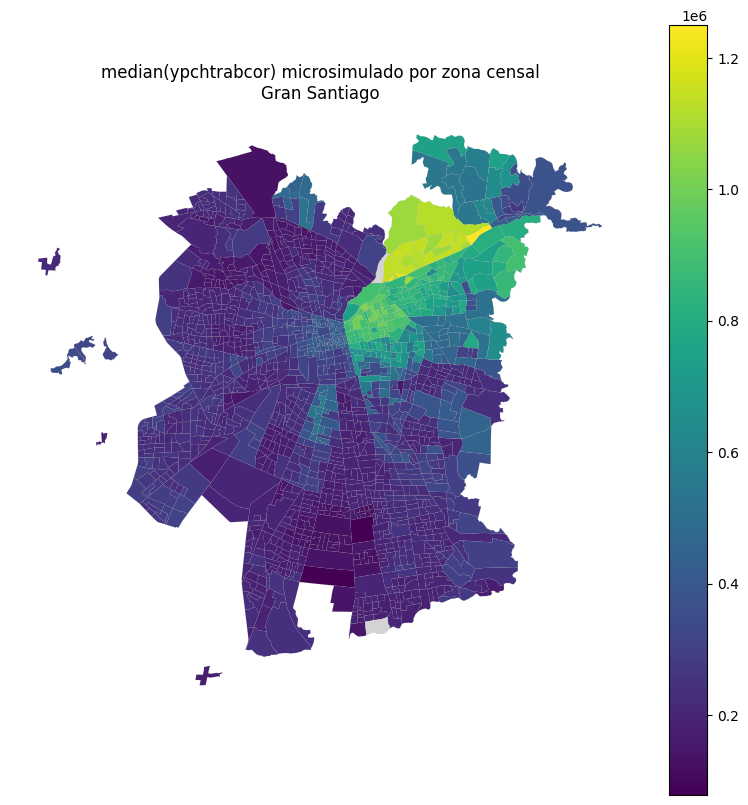

In [14]:
zonas_mapa = censo_zonal.set_index(ZONA_ID).join(resultados_zona[["valor_zona"]])

fig, ax = plt.subplots(figsize=(10, 10))
zonas_mapa.plot(
    column="valor_zona",
    cmap="viridis",
    linewidth=0.05,
    edgecolor="grey",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "sin dato"},
    ax=ax,
)
ax.set_title(f"{FUNCION_AGREGACION.__name__}({VARIABLE_A_MICROSIMULAR}) microsimulado por zona censal\nGran Santiago")
ax.set_axis_off()
plt.show()